# 📊 Day 6 — Advanced Analytics
## Bluestock Mutual Fund Capstone Project

This notebook covers six advanced analytical tasks:
1. **Historical VaR & CVaR** — Value-at-Risk and Conditional VaR for all 40 schemes
2. **Rolling 90-Day Sharpe Ratio** — Time-series visualization for 5 key funds
3. **Investor Cohort Analysis** — Behavior segmentation by first transaction year
4. **SIP Continuity Analysis** — Identifying at-risk investors based on SIP gaps
5. **Fund Recommender Demo** — Simple risk-based recommendation engine
6. **Sector HHI Concentration** — Herfindahl-Hirschman Index for equity fund portfolios

---

## 🔧 Setup & Imports

In [1]:
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Database connection
DB_PATH = '../bluestock_mf.db'
conn = sqlite3.connect(DB_PATH)
print("✅ Connected to bluestock_mf.db")

# Load core tables
dim_fund = pd.read_sql("SELECT * FROM dim_fund", conn)
fact_nav = pd.read_sql("SELECT amfi_code, date, nav FROM fact_nav", conn)
fact_nav['date'] = pd.to_datetime(fact_nav['date'])

fact_tx = pd.read_sql("SELECT * FROM fact_transactions", conn)
fact_tx['transaction_date'] = pd.to_datetime(fact_tx['transaction_date'])

holdings = pd.read_sql("SELECT * FROM portfolio_holdings", conn)

scorecard_path = '../reports/fund_scorecard.csv'
if os.path.exists(scorecard_path):
    scorecard = pd.read_csv(scorecard_path)
else:
    scorecard = pd.read_sql("SELECT * FROM fact_performance", conn)

print(f"   dim_fund: {len(dim_fund)} schemes")
print(f"   fact_nav: {len(fact_nav):,} daily NAV records across {fact_nav['amfi_code'].nunique()} schemes")
print(f"   fact_transactions: {len(fact_tx):,} transactions")
print(f"   portfolio_holdings: {len(holdings)} holdings across {holdings['amfi_code'].nunique()} funds")
print(f"   scorecard: {len(scorecard)} funds")

✅ Connected to bluestock_mf.db


   dim_fund: 40 schemes
   fact_nav: 64,320 daily NAV records across 40 schemes
   fact_transactions: 32,778 transactions
   portfolio_holdings: 322 holdings across 34 funds
   scorecard: 40 funds


---
## 📈 Task 1: Historical VaR (95%) & CVaR

**Value-at-Risk (VaR)** at the 95% confidence level is the 5th percentile of the daily return distribution — the worst daily loss you'd expect 19 out of 20 days.

**Conditional VaR (CVaR)** (Expected Shortfall) is the mean of all returns *below* the VaR threshold — the average loss on the worst 5% of days.

We compute both for all 40 schemes and export to `var_cvar_report.csv`.

In [2]:
# Compute daily returns for each scheme
nav_pivot = fact_nav.pivot_table(index='date', columns='amfi_code', values='nav')
daily_returns = nav_pivot.pct_change().dropna()

print(f"Daily returns matrix: {daily_returns.shape[0]} trading days × {daily_returns.shape[1]} schemes")
daily_returns.head()

Daily returns matrix: 1607 trading days × 40 schemes


amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632,...,120843,120844,125497,125498,148567,148568,148569,149322,149323,149324
date,,,,,,,,,,,,,,,,,,,,,
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714,...,0.018160,0.000243,0.001001,-0.005010,0.019318,0.015865,0.008378,-0.008592,0.000482,-0.010498
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913,...,-0.012304,0.000462,0.004250,-0.005184,-0.003939,-0.007660,0.015294,-0.006480,0.008670,-0.002593
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540,...,0.008509,0.000650,-0.003589,-0.002706,0.011892,-0.004709,0.000863,-0.003818,-0.013861,-0.008382
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793,...,-0.013477,0.000176,-0.002719,-0.012660,0.000515,0.007001,0.001173,-0.004069,0.004317,0.011680
2022-01-08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [3]:
# Compute VaR (95%) and CVaR for all schemes
var_results = []

for code in daily_returns.columns:
    rets = daily_returns[code].dropna()
    if len(rets) < 30:
        continue
    
    var_95 = np.percentile(rets, 5)   # 5th percentile = 95% VaR
    cvar_95 = rets[rets <= var_95].mean()  # Mean of returns below VaR
    
    fund_info = dim_fund[dim_fund['amfi_code'] == code].iloc[0]
    
    var_results.append({
        'amfi_code': code,
        'scheme_name': fund_info['scheme_name'],
        'fund_house': fund_info['fund_house'],
        'category': fund_info['category'],
        'risk_category': fund_info['risk_category'],
        'num_trading_days': len(rets),
        'mean_daily_return_pct': rets.mean() * 100,
        'std_daily_return_pct': rets.std() * 100,
        'var_95_pct': var_95 * 100,       # as percentage
        'cvar_95_pct': cvar_95 * 100,     # as percentage
    })

var_df = pd.DataFrame(var_results).sort_values('var_95_pct', ascending=True)
var_df = var_df.reset_index(drop=True)

# Save to CSV
var_df.to_csv('../reports/var_cvar_report.csv', index=False)
print(f"✅ VaR/CVaR computed for {len(var_df)} schemes → saved to reports/var_cvar_report.csv")

# Display top 10 riskiest (most negative VaR)
print("\n🔴 Top 10 Riskiest Schemes (by VaR 95%):")
display_cols = ['scheme_name', 'category', 'risk_category', 'var_95_pct', 'cvar_95_pct', 'std_daily_return_pct']
var_df[display_cols].head(10)

✅ VaR/CVaR computed for 40 schemes → saved to reports/var_cvar_report.csv

🔴 Top 10 Riskiest Schemes (by VaR 95%):


,scheme_name,category,risk_category,var_95_pct,cvar_95_pct,std_daily_return_pct
0,ABSL Small Cap Fund - Regular - Growth,Equity,Very High,-2.391462,-3.028854,1.374089
1,Axis Small Cap Fund - Regular - Growth,Equity,Very High,-2.328360,-2.969004,1.335061
2,SBI Small Cap Fund - Direct Plan - Growth,Equity,Very High,-2.315543,-3.016286,1.328865
3,Nippon India Small Cap Fund - Regular - Growth,Equity,Very High,-2.280981,-2.993962,1.344732
4,DSP Small Cap Fund - Regular - Growth,Equity,Very High,-2.152030,-2.857253,1.324078
5,SBI Small Cap Fund - Regular Plan - Growth,Equity,Very High,-2.150192,-2.844427,1.340075
6,Axis Midcap Fund - Regular - Growth,Equity,High,-1.699654,-2.237453,1.034655
7,Kotak Emerging Equity Fund - Regular - Growth,Equity,High,-1.694994,-2.125069,0.953169
8,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,High,-1.690163,-2.184984,1.009740
9,UTI Mid Cap Fund - Regular - Growth,Equity,High,-1.685705,-2.177063,0.965853


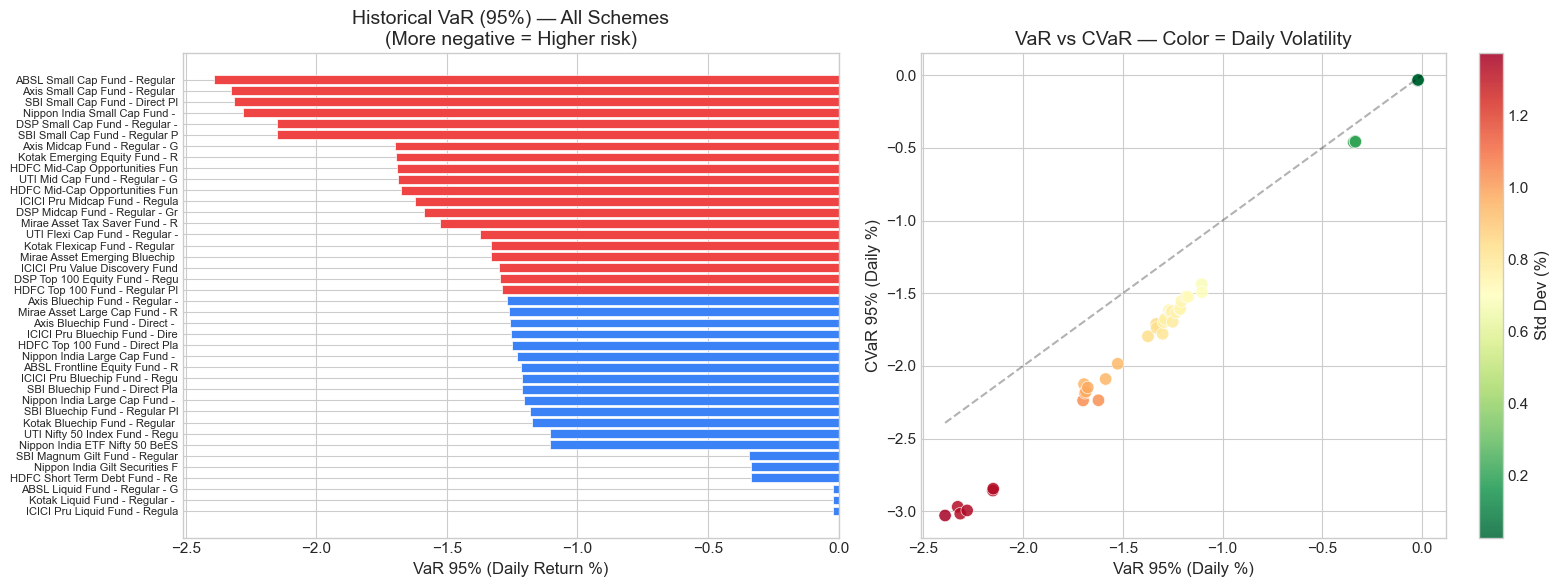

📊 Chart saved to reports/var_cvar_chart.png


In [4]:
# Visualize VaR distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: VaR by scheme (sorted)
colors = ['#EF4444' if v < var_df['var_95_pct'].median() else '#3B82F6' for v in var_df['var_95_pct']]
axes[0].barh(range(len(var_df)), var_df['var_95_pct'], color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(len(var_df)))
axes[0].set_yticklabels(var_df['scheme_name'].str[:30], fontsize=8)
axes[0].set_xlabel('VaR 95% (Daily Return %)')
axes[0].set_title('Historical VaR (95%) — All Schemes\n(More negative = Higher risk)')
axes[0].axvline(x=0, color='black', linewidth=0.5)
axes[0].invert_yaxis()

# Scatter: VaR vs CVaR
scatter = axes[1].scatter(
    var_df['var_95_pct'], var_df['cvar_95_pct'],
    c=var_df['std_daily_return_pct'], cmap='RdYlGn_r',
    s=80, edgecolors='white', linewidth=0.5, alpha=0.85
)
axes[1].set_xlabel('VaR 95% (Daily %)')
axes[1].set_ylabel('CVaR 95% (Daily %)')
axes[1].set_title('VaR vs CVaR — Color = Daily Volatility')
axes[1].plot([var_df['var_95_pct'].min(), 0], [var_df['var_95_pct'].min(), 0],
             'k--', alpha=0.3, label='VaR = CVaR line')
plt.colorbar(scatter, ax=axes[1], label='Std Dev (%)')

plt.tight_layout()
plt.savefig('../reports/var_cvar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved to reports/var_cvar_chart.png")

---
## 📉 Task 2: Rolling 90-Day Sharpe Ratio

$$\text{Rolling Sharpe} = \frac{\bar{r}_{90d}}{\sigma_{90d}} \times \sqrt{252}$$

We compute this for 5 key funds (top Sharpe from the scorecard) and plot the time series to see how risk-adjusted performance evolves.

In [5]:
# Pick top 5 funds by overall Sharpe Ratio
top5_sharpe = scorecard.nlargest(5, 'sharpe_ratio')[['amfi_code', 'scheme_name', 'sharpe_ratio']]
print("🏆 Top 5 Funds by Sharpe Ratio (used for rolling analysis):")
display(top5_sharpe)

top5_codes = top5_sharpe['amfi_code'].tolist()
top5_names = dict(zip(top5_sharpe['amfi_code'], top5_sharpe['scheme_name']))

🏆 Top 5 Funds by Sharpe Ratio (used for rolling analysis):


,amfi_code,scheme_name,sharpe_ratio
39,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.068224
37,120843,Kotak Flexicap Fund - Regular - Growth,0.965561
32,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.919047
38,120505,ICICI Pru Midcap Fund - Regular - Growth,0.883256
33,119551,SBI Bluechip Fund - Regular Plan - Growth,0.860977


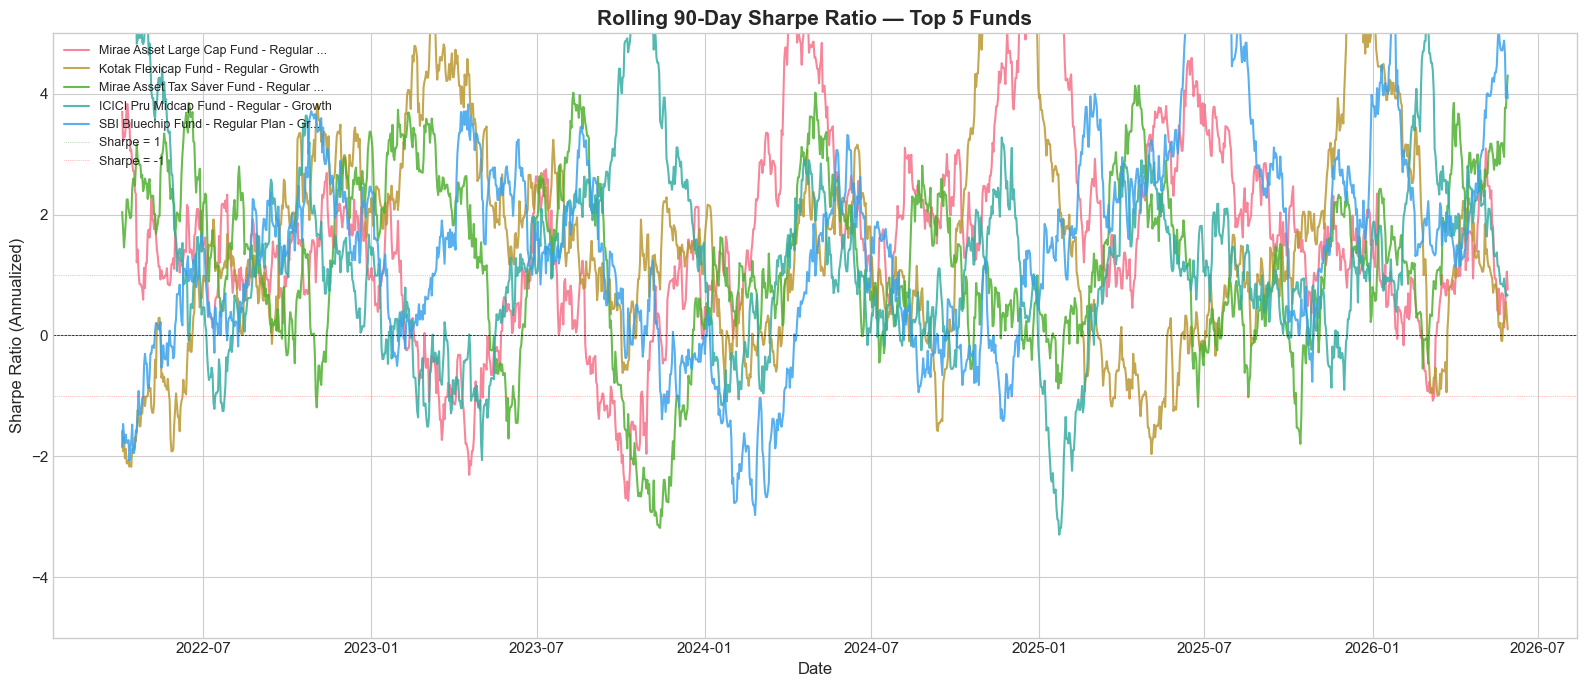

📊 Chart saved to reports/rolling_sharpe_chart.png


In [6]:
# Compute rolling 90-day Sharpe for each of the 5 funds
window = 90
annualize = np.sqrt(252)

fig, ax = plt.subplots(figsize=(16, 7))

for code in top5_codes:
    if code not in daily_returns.columns:
        continue
    rets = daily_returns[code].dropna()
    rolling_mean = rets.rolling(window).mean()
    rolling_std = rets.rolling(window).std()
    rolling_sharpe = (rolling_mean / rolling_std) * annualize
    
    label = top5_names.get(code, str(code))
    if len(label) > 40:
        label = label[:37] + '...'
    ax.plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=1.5, label=label, alpha=0.85)

ax.axhline(y=0, color='black', linewidth=0.5, linestyle='--')
ax.axhline(y=1, color='green', linewidth=0.5, linestyle=':', alpha=0.5, label='Sharpe = 1')
ax.axhline(y=-1, color='red', linewidth=0.5, linestyle=':', alpha=0.5, label='Sharpe = -1')

ax.set_title(f'Rolling {window}-Day Sharpe Ratio — Top 5 Funds', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sharpe Ratio (Annualized)')
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.set_ylim(-5, 5)

plt.tight_layout()
plt.savefig('../reports/rolling_sharpe_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Chart saved to reports/rolling_sharpe_chart.png")

---
## 👥 Task 3: Investor Cohort Analysis

Group investors by their **first transaction year** (cohort year). For each cohort, compute:
- Average SIP amount
- Total invested amount
- Top fund preference (most popular scheme)

In [7]:
# Determine each investor's cohort (first transaction year)
first_tx = fact_tx.groupby('investor_id')['transaction_date'].min().reset_index()
first_tx.columns = ['investor_id', 'first_transaction_date']
first_tx['cohort_year'] = first_tx['first_transaction_date'].dt.year

# Merge cohort info back to all transactions
tx_with_cohort = fact_tx.merge(first_tx[['investor_id', 'cohort_year']], on='investor_id')

print(f"Total investors: {tx_with_cohort['investor_id'].nunique():,}")
print(f"Cohort years: {sorted(tx_with_cohort['cohort_year'].unique())}")

Total investors: 5,000
Cohort years: [2024, 2025]


In [8]:
# Compute cohort metrics
# 1. Avg SIP amount per cohort
sip_only = tx_with_cohort[tx_with_cohort['transaction_type'] == 'SIP']
avg_sip_by_cohort = sip_only.groupby('cohort_year')['amount_inr'].mean()

# 2. Total invested per cohort (SIP + Lumpsum, exclude Redemption)
invested = tx_with_cohort[tx_with_cohort['transaction_type'].isin(['SIP', 'Lumpsum'])]
total_invested_by_cohort = invested.groupby('cohort_year')['amount_inr'].sum()

# 3. Number of investors per cohort
investors_per_cohort = tx_with_cohort.groupby('cohort_year')['investor_id'].nunique()

# 4. Top fund preference per cohort
# Get amfi_code from transactions, map to scheme_name via dim_fund
tx_with_scheme = tx_with_cohort.merge(dim_fund[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
top_fund_by_cohort = (
    tx_with_scheme.groupby('cohort_year')['scheme_name']
    .agg(lambda x: x.value_counts().index[0])
)

# Combine into a cohort summary
cohort_summary = pd.DataFrame({
    'Num Investors': investors_per_cohort,
    'Avg SIP Amount (₹)': avg_sip_by_cohort.round(0),
    'Total Invested (₹ Cr)': (total_invested_by_cohort / 1e7).round(2),
    'Top Fund Preference': top_fund_by_cohort,
})
cohort_summary.index.name = 'Cohort Year'

print("📊 Investor Cohort Summary:")
cohort_summary

📊 Investor Cohort Summary:


,Num Investors,Avg SIP Amount (₹),Total Invested (₹ Cr),Top Fund Preference
Cohort Year,,,,
2024,4803,10997.0,225.81,Mirae Asset Emerging Bluechip Fund - Regular -...
2025,197,13505.0,1.90,ICICI Pru Liquid Fund - Regular - Growth


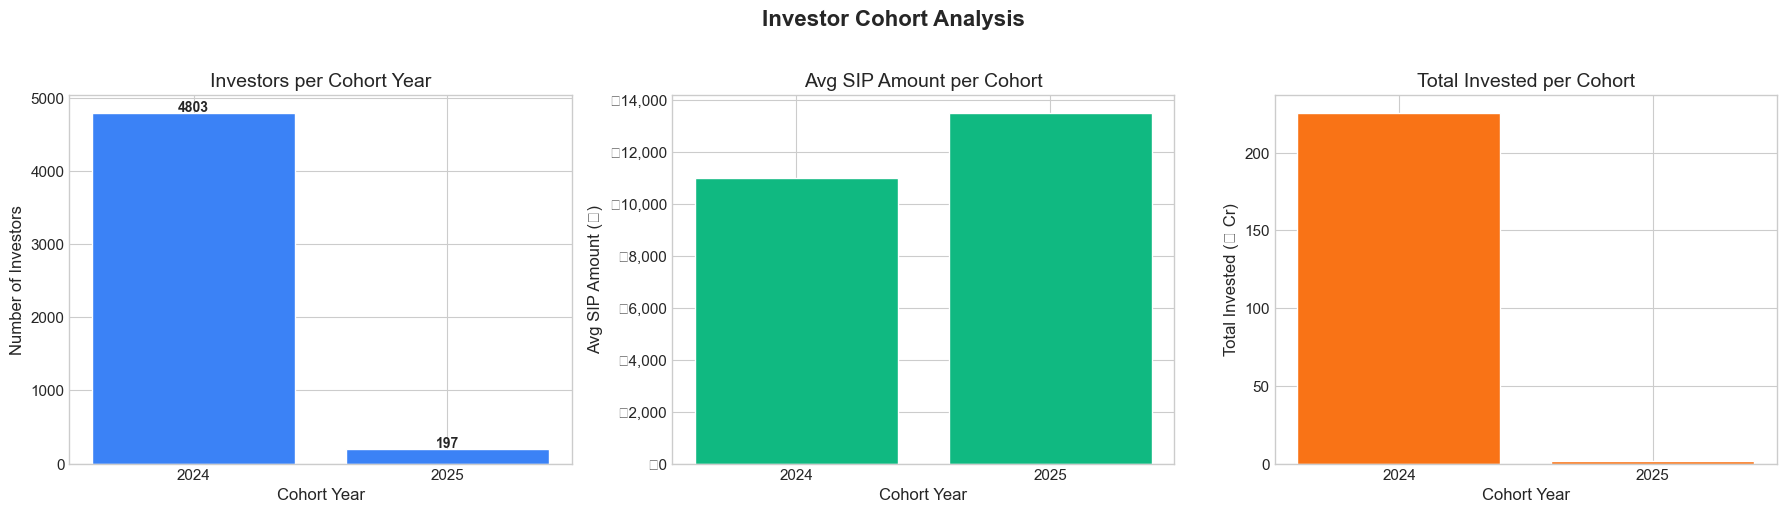

In [9]:
# Visualize cohort analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar: investors per cohort
axes[0].bar(cohort_summary.index.astype(str), cohort_summary['Num Investors'], 
            color='#3B82F6', edgecolor='white')
axes[0].set_title('Investors per Cohort Year')
axes[0].set_xlabel('Cohort Year')
axes[0].set_ylabel('Number of Investors')
for i, v in enumerate(cohort_summary['Num Investors']):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=10, fontweight='bold')

# Bar: avg SIP amount per cohort
axes[1].bar(cohort_summary.index.astype(str), cohort_summary['Avg SIP Amount (₹)'],
            color='#10B981', edgecolor='white')
axes[1].set_title('Avg SIP Amount per Cohort')
axes[1].set_xlabel('Cohort Year')
axes[1].set_ylabel('Avg SIP Amount (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

# Bar: total invested per cohort
axes[2].bar(cohort_summary.index.astype(str), cohort_summary['Total Invested (₹ Cr)'],
            color='#F97316', edgecolor='white')
axes[2].set_title('Total Invested per Cohort')
axes[2].set_xlabel('Cohort Year')
axes[2].set_ylabel('Total Invested (₹ Cr)')

plt.suptitle('Investor Cohort Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/cohort_analysis_chart.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔄 Task 4: SIP Continuity Analysis

For investors with **6+ SIP transactions**, compute the average gap (in days) between consecutive SIP dates. Flag investors with an average gap **> 35 days** as **"At-Risk"** — these are investors who may be discontinuing their SIPs.

In [10]:
# Filter to SIP transactions only
sip_tx = fact_tx[fact_tx['transaction_type'] == 'SIP'].sort_values(['investor_id', 'transaction_date'])

# Count SIPs per investor
sip_counts = sip_tx.groupby('investor_id').size()
investors_6plus = sip_counts[sip_counts >= 6].index
print(f"Investors with 6+ SIP transactions: {len(investors_6plus):,}")

# Compute avg gap between SIP dates for each qualifying investor
sip_gaps = []

for inv_id in investors_6plus:
    inv_sips = sip_tx[sip_tx['investor_id'] == inv_id]['transaction_date'].sort_values()
    gaps = inv_sips.diff().dropna().dt.days
    avg_gap = gaps.mean()
    max_gap = gaps.max()
    num_sips = len(inv_sips)
    
    sip_gaps.append({
        'investor_id': inv_id,
        'num_sips': num_sips,
        'avg_gap_days': round(avg_gap, 1),
        'max_gap_days': int(max_gap),
        'status': 'At-Risk' if avg_gap > 35 else 'Healthy',
    })

gap_df = pd.DataFrame(sip_gaps)
print(f"\n📊 SIP Continuity Summary:")
print(f"   Total investors analyzed: {len(gap_df):,}")
print(f"   Healthy (avg gap ≤ 35 days): {(gap_df['status'] == 'Healthy').sum():,}")
print(f"   At-Risk (avg gap > 35 days): {(gap_df['status'] == 'At-Risk').sum():,}")
print(f"   At-Risk Rate: {(gap_df['status'] == 'At-Risk').mean() * 100:.1f}%")

Investors with 6+ SIP transactions: 1,362



📊 SIP Continuity Summary:
   Total investors analyzed: 1,362
   Healthy (avg gap ≤ 35 days): 30
   At-Risk (avg gap > 35 days): 1,332
   At-Risk Rate: 97.8%


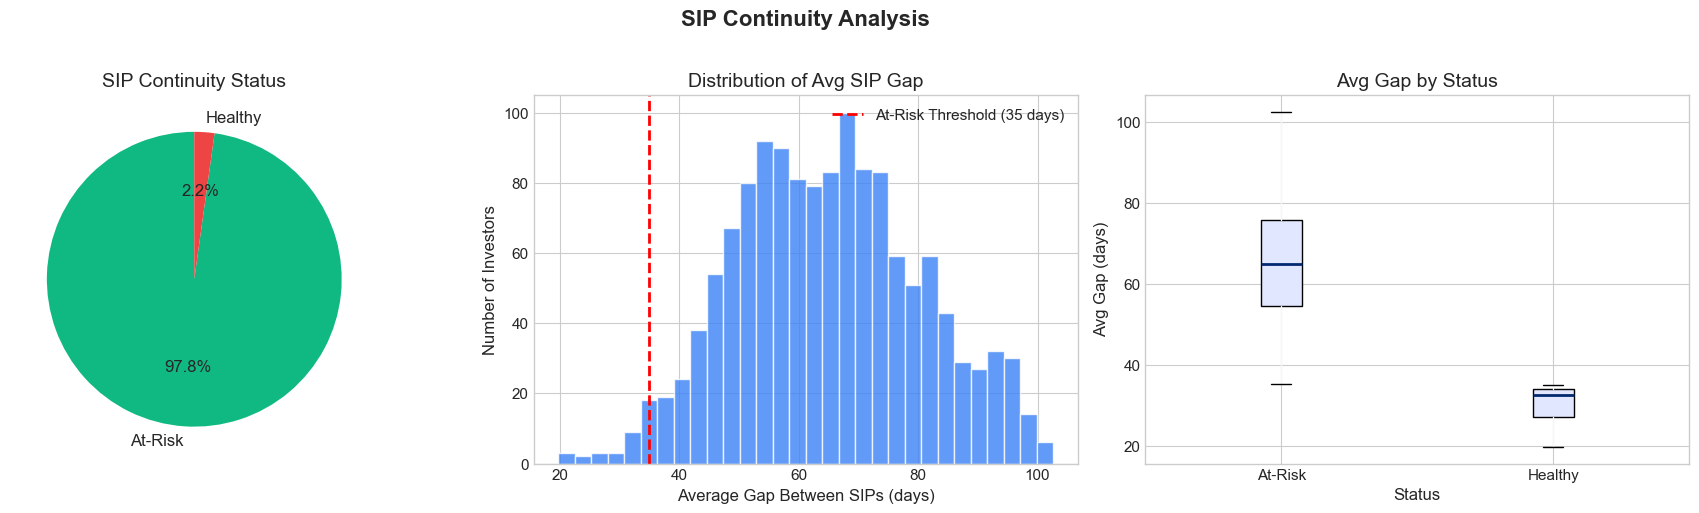

In [11]:
# Visualize SIP continuity
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pie: Healthy vs At-Risk
status_counts = gap_df['status'].value_counts()
colors_pie = ['#10B981', '#EF4444']
axes[0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%',
            colors=colors_pie, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('SIP Continuity Status')

# Histogram: avg gap distribution
axes[1].hist(gap_df['avg_gap_days'], bins=30, color='#3B82F6', edgecolor='white', alpha=0.8)
axes[1].axvline(x=35, color='red', linewidth=2, linestyle='--', label='At-Risk Threshold (35 days)')
axes[1].set_xlabel('Average Gap Between SIPs (days)')
axes[1].set_ylabel('Number of Investors')
axes[1].set_title('Distribution of Avg SIP Gap')
axes[1].legend()

# Box: gap by status
gap_df.boxplot(column='avg_gap_days', by='status', ax=axes[2],
               patch_artist=True,
               boxprops=dict(facecolor='#E0E7FF'),
               medianprops=dict(color='#012970', linewidth=2))
axes[2].set_title('Avg Gap by Status')
axes[2].set_xlabel('Status')
axes[2].set_ylabel('Avg Gap (days)')
plt.suptitle('')  # Remove auto-title from boxplot

plt.suptitle('SIP Continuity Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/sip_continuity_chart.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🎯 Task 5: Simple Fund Recommender

A simple rule-based recommender:
- **Input**: Risk appetite — `Low`, `Moderate`, or `High`
- **Logic**: Filter funds by matching `risk_category`, rank by Sharpe Ratio
- **Output**: Top 3 funds with key metrics

The standalone script is at `scripts/recommender.py`.

In [12]:
# Import the recommender module
import sys
sys.path.insert(0, '../scripts')
from recommender import recommend, RISK_MAP

# Demo for all three risk levels
for risk_level in ['Low', 'Moderate', 'High']:
    print(f"\n{'='*70}")
    print(f"  🎯 Recommendations for Risk Appetite: {risk_level}")
    print(f"     (Matching risk grades: {RISK_MAP[risk_level]})")
    print(f"{'='*70}")
    recs = recommend(risk_level)
    display(recs)


  🎯 Recommendations for Risk Appetite: Low
     (Matching risk grades: ['Low'])


,Scheme Name,Fund House,Category,Risk Grade,Sharpe Ratio,CAGR 3Y (%),Volatility (%),Score (0-100)
Rank,,,,,,,,
1,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Debt,Low,-0.743099,5.838988,3.357814,67.50
2,Nippon India Gilt Securities Fund - Regular - ...,Nippon India MF,Debt,Low,-0.850579,4.061260,3.372748,66.62
3,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Debt,Low,-1.039941,3.915479,3.304017,69.38



  🎯 Recommendations for Risk Appetite: Moderate
     (Matching risk grades: ['Moderate', 'Moderately High'])


,Scheme Name,Fund House,Category,Risk Grade,Sharpe Ratio,CAGR 3Y (%),Volatility (%),Score (0-100)
Rank,,,,,,,,
1,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Equity,Moderate,1.068224,33.991970,12.025007,16.25
2,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Equity,Moderately High,0.965561,29.575111,13.454334,20.50
3,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Equity,Moderate,0.860977,30.448613,11.636542,28.31



  🎯 Recommendations for Risk Appetite: High
     (Matching risk grades: ['High', 'Very High'])


,Scheme Name,Fund House,Category,Risk Grade,Sharpe Ratio,CAGR 3Y (%),Volatility (%),Score (0-100)
Rank,,,,,,,,
1,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset MF,Equity,High,0.919047,29.171358,14.964549,28.81
2,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Equity,High,0.883256,31.769243,16.331149,19.62
3,DSP Midcap Fund - Regular - Growth,DSP Mutual Fund,Equity,High,0.832885,26.863104,15.022898,35.75


---
## 🏗️ Task 6: Sector HHI Concentration Index

The **Herfindahl-Hirschman Index (HHI)** measures portfolio concentration:

$$\text{HHI} = \sum_{i=1}^{n} w_i^2$$

where $w_i$ is the portfolio weight of sector $i$ (as a fraction).

- **HHI ≈ 0**: Highly diversified
- **HHI ≈ 1**: Fully concentrated in one sector
- **HHI > 0.25**: Considered "highly concentrated" (equivalent to < 4 equal sectors)

We compute HHI for all equity funds with portfolio holdings data.

In [13]:
# Compute sector-level HHI for each fund
# First, aggregate weights by sector within each fund
sector_weights = holdings.groupby(['amfi_code', 'sector'])['weight_pct'].sum().reset_index()

# Normalize weights to fractions (they should sum to ~100 per fund)
total_per_fund = sector_weights.groupby('amfi_code')['weight_pct'].sum().reset_index()
total_per_fund.columns = ['amfi_code', 'total_weight']
sector_weights = sector_weights.merge(total_per_fund, on='amfi_code')
sector_weights['weight_frac'] = sector_weights['weight_pct'] / sector_weights['total_weight']

# Compute HHI = sum of squared weight fractions
sector_weights['w_squared'] = sector_weights['weight_frac'] ** 2
hhi_per_fund = sector_weights.groupby('amfi_code')['w_squared'].sum().reset_index()
hhi_per_fund.columns = ['amfi_code', 'hhi']

# Number of sectors per fund
num_sectors = sector_weights.groupby('amfi_code')['sector'].nunique().reset_index()
num_sectors.columns = ['amfi_code', 'num_sectors']

# Merge with fund info
hhi_df = hhi_per_fund.merge(dim_fund[['amfi_code', 'scheme_name', 'fund_house', 'category']], on='amfi_code')
hhi_df = hhi_df.merge(num_sectors, on='amfi_code')
hhi_df = hhi_df.sort_values('hhi', ascending=False).reset_index(drop=True)

# Classify concentration
hhi_df['concentration'] = pd.cut(hhi_df['hhi'],
                                  bins=[0, 0.15, 0.25, 1.0],
                                  labels=['Diversified', 'Moderate', 'Concentrated'])

print(f"📊 HHI Computed for {len(hhi_df)} equity funds with holdings data")
print(f"\nConcentration Distribution:")
print(hhi_df['concentration'].value_counts().to_string())
print(f"\n🔝 Most Concentrated Funds:")
hhi_df[['scheme_name', 'category', 'num_sectors', 'hhi', 'concentration']].head(10)

📊 HHI Computed for 34 equity funds with holdings data

Concentration Distribution:
concentration
Moderate        27
Concentrated     4
Diversified      3

🔝 Most Concentrated Funds:


,scheme_name,category,num_sectors,hhi,concentration
0,Axis Bluechip Fund - Regular - Growth,Equity,7,0.296828,Concentrated
1,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,7,0.255094,Concentrated
2,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity,6,0.253155,Concentrated
3,UTI Flexi Cap Fund - Regular - Growth,Equity,6,0.251332,Concentrated
4,DSP Midcap Fund - Regular - Growth,Equity,7,0.241077,Moderate
5,ICICI Pru Midcap Fund - Regular - Growth,Equity,7,0.238600,Moderate
6,Nippon India ETF Nifty 50 BeES,Equity,6,0.237544,Moderate
7,SBI Small Cap Fund - Direct Plan - Growth,Equity,7,0.232361,Moderate
8,ICICI Pru Value Discovery Fund - Regular - Growth,Equity,7,0.231372,Moderate
9,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,7,0.227647,Moderate


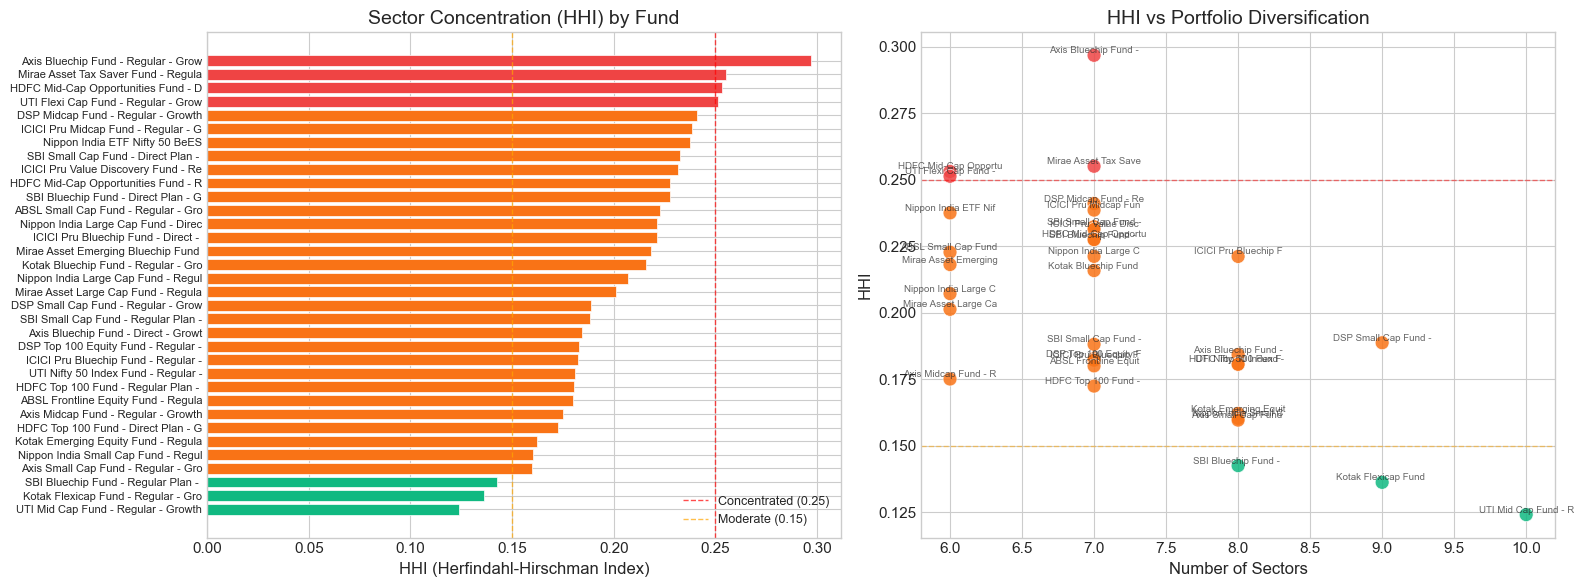

In [14]:
# Visualize HHI
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: HHI by fund
colors_hhi = ['#EF4444' if h > 0.25 else '#F97316' if h > 0.15 else '#10B981' for h in hhi_df['hhi']]
axes[0].barh(range(len(hhi_df)), hhi_df['hhi'], color=colors_hhi, edgecolor='white', linewidth=0.5)
axes[0].set_yticks(range(len(hhi_df)))
axes[0].set_yticklabels(hhi_df['scheme_name'].str[:35], fontsize=8)
axes[0].set_xlabel('HHI (Herfindahl-Hirschman Index)')
axes[0].set_title('Sector Concentration (HHI) by Fund')
axes[0].axvline(x=0.25, color='red', linewidth=1, linestyle='--', alpha=0.7, label='Concentrated (0.25)')
axes[0].axvline(x=0.15, color='orange', linewidth=1, linestyle='--', alpha=0.7, label='Moderate (0.15)')
axes[0].legend(loc='lower right', fontsize=9)
axes[0].invert_yaxis()

# Scatter: HHI vs Number of Sectors
axes[1].scatter(hhi_df['num_sectors'], hhi_df['hhi'], c=colors_hhi,
                s=100, edgecolors='white', linewidth=0.5, alpha=0.85)
axes[1].set_xlabel('Number of Sectors')
axes[1].set_ylabel('HHI')
axes[1].set_title('HHI vs Portfolio Diversification')
axes[1].axhline(y=0.25, color='red', linewidth=1, linestyle='--', alpha=0.5)
axes[1].axhline(y=0.15, color='orange', linewidth=1, linestyle='--', alpha=0.5)

for _, row in hhi_df.iterrows():
    axes[1].annotate(row['scheme_name'][:20], (row['num_sectors'], row['hhi']),
                     fontsize=7, alpha=0.7, ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../reports/hhi_concentration_chart.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 💡 Task 7: Five Advanced Insights

### Insight 1: Highest VaR Schemes — Risk Hotspots

In [15]:
# Insight 1: Top 5 riskiest schemes by VaR
print("🔴 INSIGHT 1: Schemes with Highest Value-at-Risk (Most Risky)")
print("=" * 70)
top_risk = var_df.head(5)[['scheme_name', 'category', 'risk_category', 'var_95_pct', 'cvar_95_pct']]
top_risk.columns = ['Scheme', 'Category', 'Risk Grade', 'VaR 95% (%)', 'CVaR 95% (%)']
display(top_risk)
print(f"\n→ The riskiest fund has a daily VaR of {var_df.iloc[0]['var_95_pct']:.2f}%,")
print(f"  meaning on the worst 5% of days, investors could lose {abs(var_df.iloc[0]['var_95_pct']):.2f}%+ of their portfolio value.")
print(f"  The CVaR (avg loss on those worst days) is {var_df.iloc[0]['cvar_95_pct']:.2f}%.")

🔴 INSIGHT 1: Schemes with Highest Value-at-Risk (Most Risky)


,Scheme,Category,Risk Grade,VaR 95% (%),CVaR 95% (%)
0,ABSL Small Cap Fund - Regular - Growth,Equity,Very High,-2.391462,-3.028854
1,Axis Small Cap Fund - Regular - Growth,Equity,Very High,-2.328360,-2.969004
2,SBI Small Cap Fund - Direct Plan - Growth,Equity,Very High,-2.315543,-3.016286
3,Nippon India Small Cap Fund - Regular - Growth,Equity,Very High,-2.280981,-2.993962
4,DSP Small Cap Fund - Regular - Growth,Equity,Very High,-2.152030,-2.857253



→ The riskiest fund has a daily VaR of -2.39%,
  meaning on the worst 5% of days, investors could lose 2.39%+ of their portfolio value.
  The CVaR (avg loss on those worst days) is -3.03%.


### Insight 2: Investor Cohort Behavior — Who Invests Most?

In [16]:
# Insight 2: Which cohort invests the most?
print("👥 INSIGHT 2: Investor Cohort — Investment Patterns")
print("=" * 70)
display(cohort_summary)
biggest_cohort = cohort_summary['Total Invested (₹ Cr)'].idxmax()
highest_sip = cohort_summary['Avg SIP Amount (₹)'].idxmax()
print(f"\n→ The {biggest_cohort} cohort has invested the most: ₹{cohort_summary.loc[biggest_cohort, 'Total Invested (₹ Cr)']:.2f} Cr")
print(f"→ The {highest_sip} cohort has the highest avg SIP amount: ₹{cohort_summary.loc[highest_sip, 'Avg SIP Amount (₹)']:,.0f}")

👥 INSIGHT 2: Investor Cohort — Investment Patterns


,Num Investors,Avg SIP Amount (₹),Total Invested (₹ Cr),Top Fund Preference
Cohort Year,,,,
2024,4803,10997.0,225.81,Mirae Asset Emerging Bluechip Fund - Regular -...
2025,197,13505.0,1.90,ICICI Pru Liquid Fund - Regular - Growth



→ The 2024 cohort has invested the most: ₹225.81 Cr
→ The 2025 cohort has the highest avg SIP amount: ₹13,505


### Insight 3: SIP Continuity Rate — Investor Retention Health

In [17]:
# Insight 3: SIP continuity rate
print("🔄 INSIGHT 3: SIP Continuity Rate")
print("=" * 70)
healthy_pct = (gap_df['status'] == 'Healthy').mean() * 100
at_risk_pct = (gap_df['status'] == 'At-Risk').mean() * 100
avg_healthy_gap = gap_df[gap_df['status'] == 'Healthy']['avg_gap_days'].mean()
avg_atrisk_gap = gap_df[gap_df['status'] == 'At-Risk']['avg_gap_days'].mean()

print(f"   SIP Continuity Rate (Healthy): {healthy_pct:.1f}%")
print(f"   At-Risk Rate: {at_risk_pct:.1f}%")
print(f"   Avg gap for Healthy investors: {avg_healthy_gap:.1f} days")
print(f"   Avg gap for At-Risk investors: {avg_atrisk_gap:.1f} days")
print(f"\n→ {healthy_pct:.0f}% of regular SIP investors maintain healthy continuity (≤35 day gaps).")
print(f"   The {at_risk_pct:.0f}% at-risk investors show avg gaps of {avg_atrisk_gap:.0f} days — potential churn candidates.")

🔄 INSIGHT 3: SIP Continuity Rate
   SIP Continuity Rate (Healthy): 2.2%
   At-Risk Rate: 97.8%
   Avg gap for Healthy investors: 30.3 days
   Avg gap for At-Risk investors: 65.7 days

→ 2% of regular SIP investors maintain healthy continuity (≤35 day gaps).
   The 98% at-risk investors show avg gaps of 66 days — potential churn candidates.


### Insight 4: Portfolio Concentration — Diversification Gap

In [18]:
# Insight 4: HHI concentration insight
print("🏗️ INSIGHT 4: Portfolio Concentration — Diversification Gap")
print("=" * 70)
concentrated = hhi_df[hhi_df['concentration'] == 'Concentrated']
diversified = hhi_df[hhi_df['concentration'] == 'Diversified']

print(f"   Concentrated funds (HHI > 0.25): {len(concentrated)}")
print(f"   Diversified funds (HHI < 0.15): {len(diversified)}")

if len(concentrated) > 0:
    print(f"\n   Most concentrated fund: {concentrated.iloc[0]['scheme_name']}")
    print(f"   → HHI = {concentrated.iloc[0]['hhi']:.4f}, across {concentrated.iloc[0]['num_sectors']} sectors")

if len(diversified) > 0:
    print(f"\n   Most diversified fund: {diversified.iloc[-1]['scheme_name']}")
    print(f"   → HHI = {diversified.iloc[-1]['hhi']:.4f}, across {diversified.iloc[-1]['num_sectors']} sectors")

🏗️ INSIGHT 4: Portfolio Concentration — Diversification Gap
   Concentrated funds (HHI > 0.25): 4
   Diversified funds (HHI < 0.15): 3

   Most concentrated fund: Axis Bluechip Fund - Regular - Growth
   → HHI = 0.2968, across 7 sectors

   Most diversified fund: UTI Mid Cap Fund - Regular - Growth
   → HHI = 0.1241, across 10 sectors


### Insight 5: Sharpe Ratio Stability — Consistent vs Volatile Performers

In [19]:
# Insight 5: Rolling Sharpe stability
print("📉 INSIGHT 5: Sharpe Ratio Stability — Who Stays Consistent?")
print("=" * 70)

sharpe_stats = []
for code in daily_returns.columns:
    rets = daily_returns[code].dropna()
    if len(rets) < 90:
        continue
    rolling_sharpe = (rets.rolling(90).mean() / rets.rolling(90).std()) * np.sqrt(252)
    rolling_sharpe = rolling_sharpe.dropna()
    
    fund_info = dim_fund[dim_fund['amfi_code'] == code]
    if fund_info.empty:
        continue
    
    sharpe_stats.append({
        'scheme_name': fund_info.iloc[0]['scheme_name'],
        'category': fund_info.iloc[0]['category'],
        'mean_rolling_sharpe': rolling_sharpe.mean(),
        'std_rolling_sharpe': rolling_sharpe.std(),
        'pct_positive_sharpe': (rolling_sharpe > 0).mean() * 100,
    })

sharpe_stability = pd.DataFrame(sharpe_stats)
sharpe_stability['consistency_score'] = (
    sharpe_stability['mean_rolling_sharpe'] / sharpe_stability['std_rolling_sharpe'].clip(lower=0.01)
)
sharpe_stability = sharpe_stability.sort_values('consistency_score', ascending=False)

print("\n🏆 Most Consistent Performers (highest mean Sharpe / lowest Sharpe volatility):")
display(sharpe_stability[['scheme_name', 'category', 'mean_rolling_sharpe', 'std_rolling_sharpe',
                           'pct_positive_sharpe', 'consistency_score']].head(5).round(2))

print(f"\n→ The most consistent fund maintains a positive rolling Sharpe {sharpe_stability.iloc[0]['pct_positive_sharpe']:.0f}% of the time.")
print(f"   Consistency score (mean/std of rolling Sharpe) = {sharpe_stability.iloc[0]['consistency_score']:.2f}")

📉 INSIGHT 5: Sharpe Ratio Stability — Who Stays Consistent?



🏆 Most Consistent Performers (highest mean Sharpe / lowest Sharpe volatility):


,scheme_name,category,mean_rolling_sharpe,std_rolling_sharpe,pct_positive_sharpe,consistency_score
27,ICICI Pru Liquid Fund - Regular - Growth,Debt,10.40,1.26,100.00,8.26
31,Kotak Liquid Fund - Regular - Growth,Debt,9.73,1.36,100.00,7.13
5,ABSL Liquid Fund - Regular - Growth,Debt,9.41,1.35,100.00,6.97
6,UTI Nifty 50 Index Fund - Regular - Growth,Equity,1.18,1.11,82.54,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Equity,1.61,1.64,86.69,0.98



→ The most consistent fund maintains a positive rolling Sharpe 100% of the time.
   Consistency score (mean/std of rolling Sharpe) = 8.26


---
## ✅ Summary & Deliverables

| Deliverable | Status |
|---|---|
| `reports/var_cvar_report.csv` | ✅ Generated |
| `reports/rolling_sharpe_chart.png` | ✅ Generated |
| `scripts/recommender.py` | ✅ Created |
| `Advanced_Analytics.ipynb` | ✅ This notebook |

---
*Bluestock Mutual Fund Capstone — Day 6 Advanced Analytics*

In [20]:
# Close database connection
conn.close()
print("✅ All Day 6 analyses complete. Database connection closed.")

✅ All Day 6 analyses complete. Database connection closed.
